In [66]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

# Loading data

In [67]:
import kagglehub
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\dashu\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2


In [68]:
META_PATH = os.path.join(path, 'HAM10000_metadata.csv')
IMG_DIRS = [
    os.path.join(path, 'HAM10000_images_part_1'),
    os.path.join(path, 'HAM10000_images_part_2'),
]

# Load metadata
df = pd.read_csv(META_PATH)

print(f'Rows loaded : {len(df)}')
df.head()

Rows loaded : 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [69]:
print("Diagnosis:")
print(df["dx"].unique().tolist())
print("Diagnosis types:")
print(df["dx_type"].unique().tolist())
print("Sex:")
print(df["sex"].unique().tolist())
print("Localization:")
print(df["localization"].unique().tolist())

Diagnosis:
['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']
Diagnosis types:
['histo', 'consensus', 'confocal', 'follow_up']
Sex:
['male', 'female', 'unknown']
Localization:
['scalp', 'ear', 'face', 'back', 'trunk', 'chest', 'upper extremity', 'abdomen', 'unknown', 'lower extremity', 'genital', 'neck', 'hand', 'foot', 'acral']


In [70]:
print('Column types:')
print(df.dtypes)

Column types:
lesion_id           str
image_id            str
dx                  str
dx_type             str
age             float64
sex                 str
localization        str
dtype: object


# Pre-processing data

In [71]:
LABEL_MAP = {
    'nv'  : 'Melanocytic Nevi',
    'mel' : 'Melanoma',
    'bkl' : 'Benign Keratosis',
    'bcc' : 'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratoses / Intraep. Carcinoma',
    'vasc': 'Vascular Lesions',
    'df'  : 'Dermatofibroma',
}
MALIGNANT = {'mel', 'bcc', 'akiec'} # high-risk

df['dx_full'] = df['dx'].map(LABEL_MAP)
df['malignant'] = df['dx'].isin(MALIGNANT)

In [72]:
# Build image path lookup
image_paths = {}
for d in IMG_DIRS:
    if os.path.isdir(d):
        for fp in glob.glob(os.path.join(d, '*.jpg')):
            image_paths[os.path.splitext(os.path.basename(fp))[0]] = fp

df['image_path'] = df['image_id'].map(image_paths)

print(f'Images found: {df["image_path"].notna().sum()}')
df.head()

Images found: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,dx_full,malignant,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,Benign Keratosis,False,C:\Users\dashu\.cache\kagglehub\datasets\kmade...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,Benign Keratosis,False,C:\Users\dashu\.cache\kagglehub\datasets\kmade...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,Benign Keratosis,False,C:\Users\dashu\.cache\kagglehub\datasets\kmade...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,Benign Keratosis,False,C:\Users\dashu\.cache\kagglehub\datasets\kmade...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,Benign Keratosis,False,C:\Users\dashu\.cache\kagglehub\datasets\kmade...


In [73]:
print(f'Unique patients (lesion_id): {df["lesion_id"].nunique()}')
print(f'Unique images IDs: {df["image_id"].nunique()}')
print(f'Diagnosis classes: {df["dx"].nunique()}')
print(F'Shape : {df.shape}')

Unique patients (lesion_id): 7470
Unique images IDs: 10015
Diagnosis classes: 7
Shape : (10015, 10)


In [74]:
print('Missing values:')
missing = df.isnull().sum()
print(missing[missing > 0])

Missing values:
age    57
dtype: int64


In [75]:
df.describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


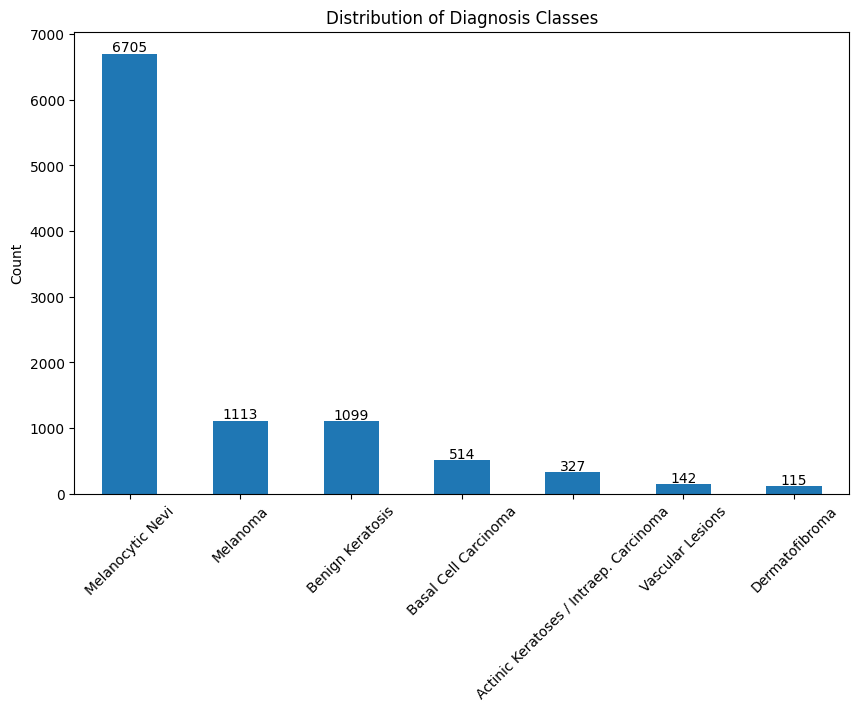

In [87]:
class_counts = df['dx_full'].value_counts()
class_counts.plot(kind='bar', figsize=(10, 6))
plt.title('Distribution of Diagnosis Classes')
plt.xlabel('')
plt.ylabel('Count')
plt.xticks(rotation=45)
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontsize=10)

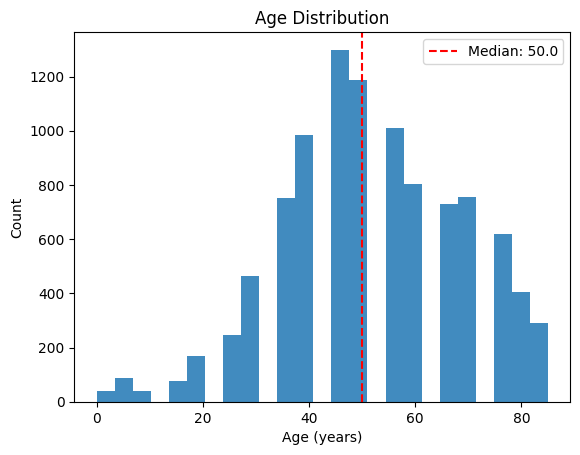

In [86]:
plt.hist(df['age'].dropna(), bins=25, alpha=0.85)
plt.axvline(df['age'].median(), color='red', linestyle='--', label=f'Median: {df["age"].median()}')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.legend()

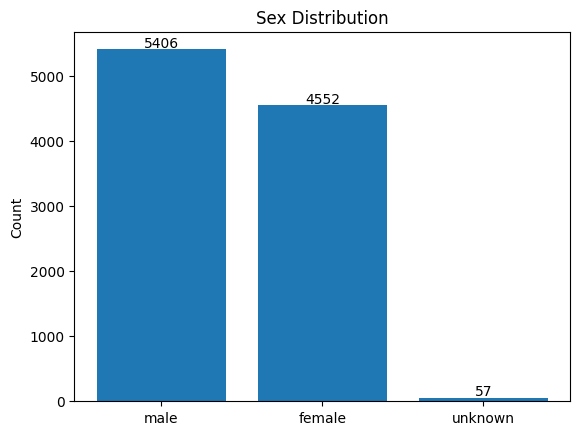

In [78]:
sex_counts = df['sex'].value_counts()
plt.bar(sex_counts.index, sex_counts.values)
plt.title('Sex Distribution')
plt.ylabel('Count')
for i, v in enumerate(sex_counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontsize=10)

Text(0, 0.5, '')

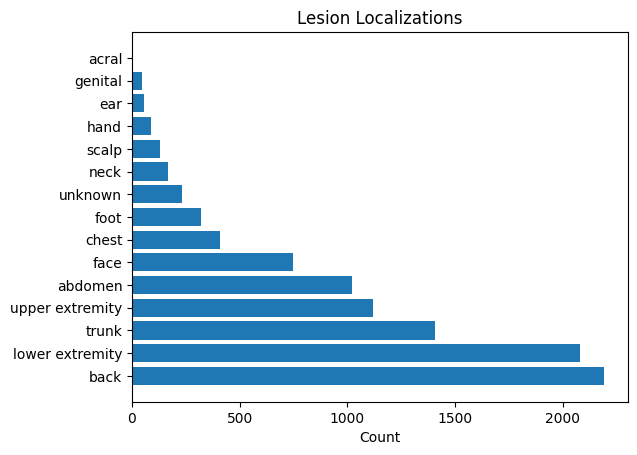

In [88]:
loc_counts = df['localization'].value_counts()
plt.barh(loc_counts.index, loc_counts.values)
plt.title('Lesion Localizations')
plt.xlabel('Count')
plt.ylabel('')

Text(0.5, 1.0, 'Malignant vs Benign Breakdown')

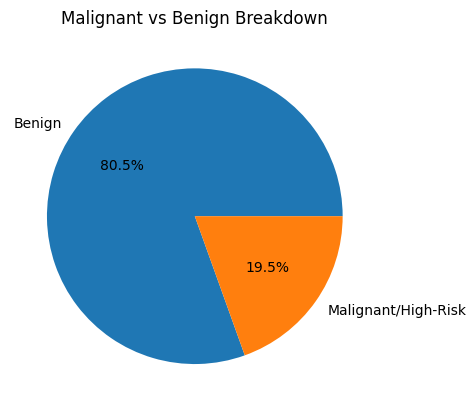

In [80]:
mal_counts = df['malignant'].map({True: 'Malignant/High-Risk', False: 'Benign'}).value_counts()
plt.pie(mal_counts.values, labels=mal_counts.index, autopct='%1.1f%%')
plt.title('Malignant vs Benign Breakdown')

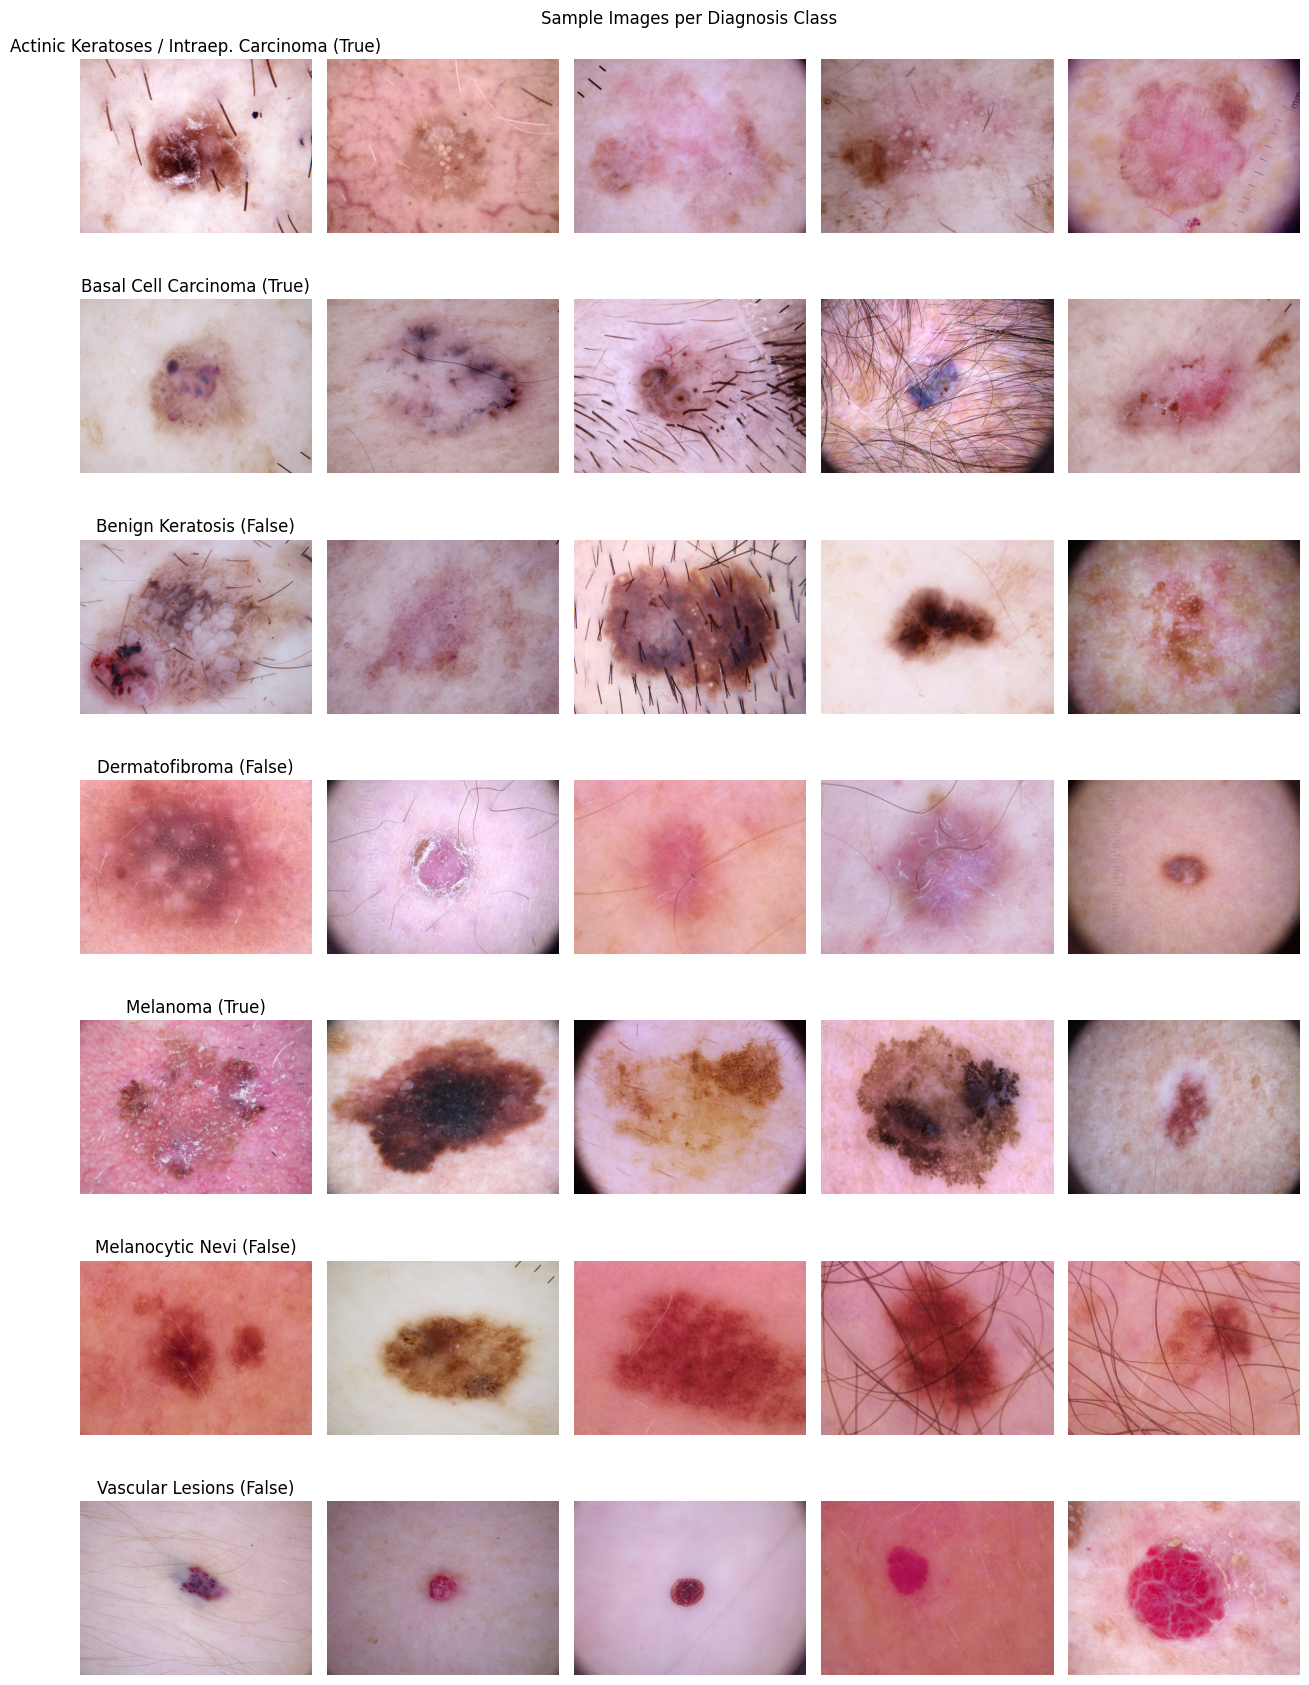

In [81]:

classes = sorted(df['dx'].unique())
n_classes = len(classes)
fig, axes = plt.subplots(n_classes, 5,
    figsize=(5 * 2.5, n_classes * 2.5))

for row_idx, dx in enumerate(classes):
    subset = df[df['dx'] == dx]
    samples = subset.sample(min(5, len(subset)))

    for col_idx in range(5):
        ax = axes[row_idx][col_idx]
        img = Image.open(samples.iloc[col_idx]['image_path'])
        ax.imshow(img)

        ax.axis('off')
        if col_idx == 0:
            m = samples.iloc[col_idx]['malignant']
            ax.set_title(f'{LABEL_MAP[dx]} ({m})')

plt.suptitle('Sample Images per Diagnosis Class')
plt.tight_layout()
plt.show()


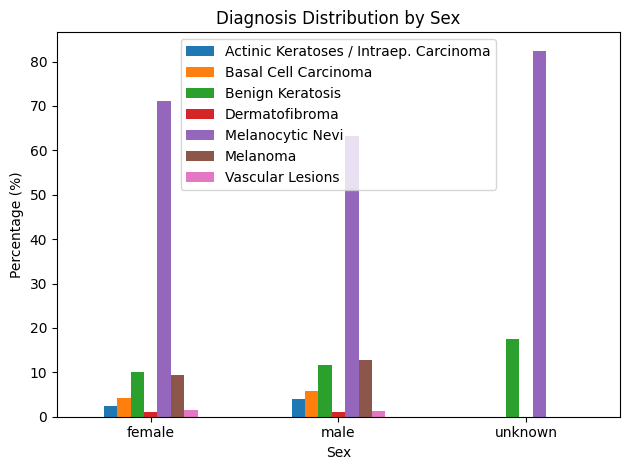

In [82]:
cross = pd.crosstab(df['sex'], df['dx_full'], normalize='index') * 100
cross.plot(kind='bar')
plt.title('Diagnosis Distribution by Sex')
plt.xlabel('Sex')
plt.ylabel('Percentage (%)')
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()

In [89]:
subset = df['image_path'].notna()
records = []
for _, row in df[subset].sample(n=2000).iterrows():
    arr = np.array(Image.open(row['image_path']), dtype=np.float32)
    records.append({
        'dx': row['dx'],
        'brightness': arr.mean(),
        'contrast': arr.std(),
        'width': arr.shape[1],
        'height': arr.shape[0],
    })

df_stat = pd.DataFrame(records)

In [90]:
df_stat.describe()

,brightness,contrast,width,height
count,2000.000000,2000.000000,2000.0,2000.0
mean,159.418518,41.570396,600.0,450.0
std,18.951162,11.767191,0.0,0.0
min,95.958344,12.113726,600.0,450.0
25%,146.439137,32.376214,600.0,450.0
50%,159.774658,42.395039,600.0,450.0
75%,172.174816,50.364629,600.0,450.0
max,222.853348,81.799545,600.0,450.0


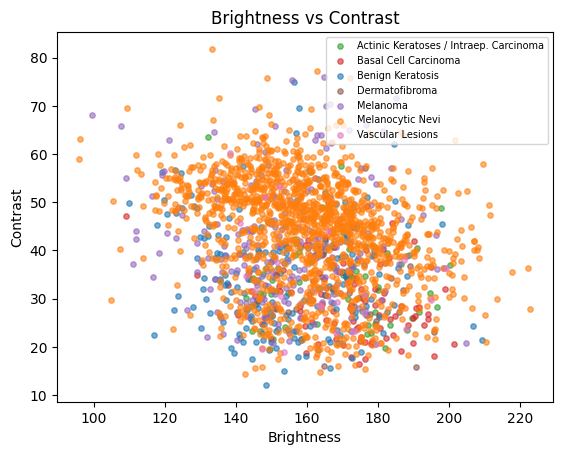

In [91]:
palette = dict(zip(df_stat['dx'].unique(),
                       sns.color_palette('tab10', df_stat['dx'].nunique())))
for dx_code, grp in df_stat.groupby('dx'):
    plt.scatter(grp['brightness'], grp['contrast'], s=15, alpha=0.6,
                    label=LABEL_MAP[dx_code], color=palette[dx_code])
plt.title('Brightness vs Contrast')
plt.xlabel('Brightness')
plt.ylabel('Contrast')
plt.legend(fontsize=7)